In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import scipy.interpolate as interpolate

# Funzione gaussiana
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Apri il file ROOT
file = uproot.open("/home/riccardo-speziali/after_waveforms_analysis/sampic_mcp_setup_run227_final.root")
tree = file["picoTree"]

# Converti in Awkward Array
data = tree.arrays(library="ak")

# Estrai branch rilevanti
Cell0TimeStamp_PICOSEC = data["Cell0timeSTamp_PICOSEC"]  # array di array
Cell0TimeStamp_MCP    = data["Cell0timestamp_MCP"]       # array piatto
cfd_PICO              = data["pulses_time_cfd30"]       # array di array
cfd_MCP               = data["mcp_time_cfd30"]          # array piatto
hits                  = data["hit_x_event"]             # numero di hit per evento
channel               = data["chanel_PICOSEC"]         # canale PICOSEC
srs                   = data["TriggerIDSRS_MCP"]      # Trigger ID SRS
amplitude_PICOSEC     = data["pulses_amplitude"]     # array di array
e_peak_PICOSEC        = data["pulses_integral"]        # array di array
track_chi_2          = data["track_chi_2"]             # chi2 del track




num_channel = 93

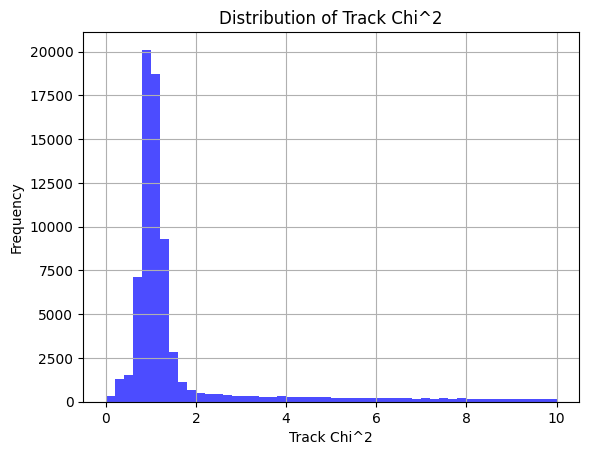

In [2]:
#fit track chi_2
chi_2_values = ak.to_numpy(track_chi_2)
chi_2_values = chi_2_values[~np.isnan(chi_2_values)]
plt.hist(chi_2_values, bins=50, range=(0, 10), alpha=0.7, color='blue')
plt.xlabel('Track Chi^2')
plt.ylabel('Frequency')
plt.title('Distribution of Track Chi^2')
plt.grid()
plt.show()

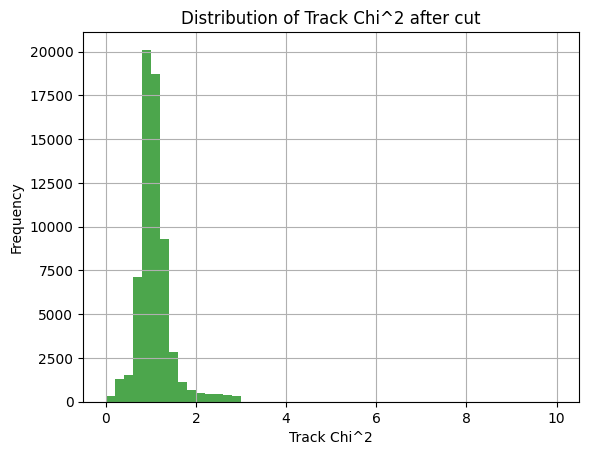

In [3]:
#keep events with good track fit anche per eventi con più di un hit
good_track_mask = chi_2_values < 3
good_tracks = ak.mask(track_chi_2, good_track_mask)
#plot track chi_2 distribution after cut
good_chi_2_values = ak.to_numpy(good_tracks)
good_chi_2_values = good_chi_2_values[~np.isnan(good_chi_2_values)]
plt.hist(good_chi_2_values, bins=50, range=(0, 10), alpha=0.7, color='green')
plt.xlabel('Track Chi^2')
plt.ylabel('Frequency')
plt.title('Distribution of Track Chi^2 after cut')
plt.grid()
plt.show()



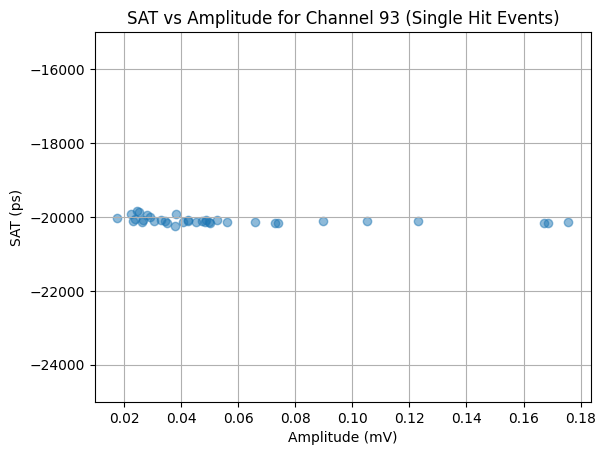

0.17573118209838867


/tmp/ipykernel_37958/3427942552.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, sigma=err, absolute_sigma=True)


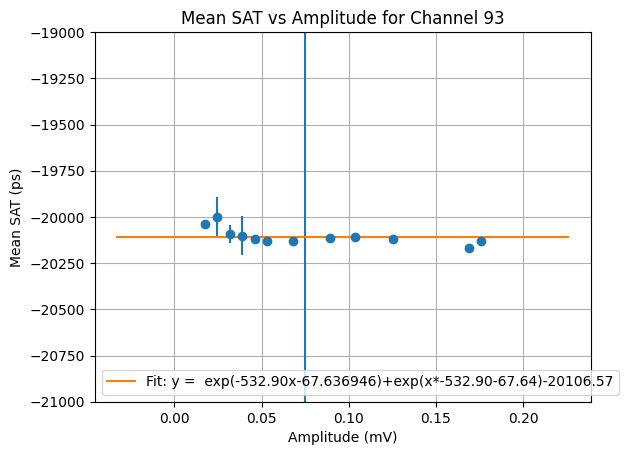

In [4]:
channel_mask = channel[:, 0] == num_channel
single_hit_mask = hits == 1

valid_mask = (
    (ak.num(amplitude_PICOSEC) >= 1) &
    (ak.num(cfd_PICO) >= 1) &
    good_track_mask
)

event_mask = channel_mask & single_hit_mask & valid_mask

good_amplitude = amplitude_PICOSEC[event_mask][:,0]





good_SAT = (cfd_PICO[event_mask][:,0] - cfd_MCP[event_mask] - (Cell0TimeStamp_MCP[event_mask]*1e3-Cell0TimeStamp_PICOSEC[event_mask][:,0]*1e3))





plt.scatter(good_amplitude, good_SAT, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('SAT (ps)')
plt.title(f'SAT vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.ylim(-25000,-15000)
plt.grid()
plt.show()



#altro plot dividere il grafico in bin e prendere la media per ogni bin
bins = np.linspace(ak.min(good_amplitude)-1, ak.max(good_amplitude)+1, 300)
bin_indices = np.digitize(good_amplitude, bins)
print(ak.max(good_amplitude))

bin_means = []
bin_std = []
bin_echarge_means = []
bin_echarge_std = []
for i in range(1, len(bins)):
    mask = bin_indices == i
    if ak.sum(mask) > 0:
        bin_means.append(ak.mean(good_SAT[mask]))
        bin_std.append(ak.std(good_SAT[mask]))
        bin_echarge_means.append(ak.mean(e_peak_PICOSEC[event_mask][:,0][mask]))
        bin_echarge_std.append(ak.std(e_peak_PICOSEC[event_mask][:,0][mask]))
    else:
        bin_means.append(np.nan)
        bin_std.append(np.nan)
        bin_echarge_means.append(np.nan)
        bin_echarge_std.append(np.nan)

bin_centers = 0.5 * (bins[:-1] + bins[1:])




# converti in NumPy
bin_means_np = ak.to_numpy(bin_means)
bin_std_np = ak.to_numpy(bin_std)
bin_centers_np = ak.to_numpy(bin_centers)

# filtro valori validi
mask = (~np.isnan(bin_means_np)) & (bin_centers_np > 0)
x = bin_centers_np[mask]
y = bin_means_np[mask]
err = bin_std_np[mask]

# fix valori critici
x = x + 1e-6                # evita log(0)
err = np.where(np.isnan(err) | (err == 0), 1e-6, err)

# funzione logaritmica
def func(x,a,b,c,d,e):
    return   np.exp(x*a+b)+np.exp(x*c+d)+e

# fit pesato
#bounds = ([0, -np.inf,-np.inf], [2, np.inf,np.inf])

popt, pcov = curve_fit(func, x, y, sigma=err, absolute_sigma=True)
a,b, c,d,e= popt

# curva fittata
x_fit = np.linspace(min(x)-0.05, max(x)+0.05, 100)
y_fit = func(x_fit, a,b,c,d,e)

# plot
plt.errorbar(x, y, err, marker='o', linestyle='none')
plt.plot(x_fit, y_fit, label=f'Fit: y =  exp({a:.2f}x{b:2f})+exp(x*{c:.2f}{d:.2f}){e:.2f}')
plt.xlabel('Amplitude (mV)')
plt.ylabel('Mean SAT (ps)')
plt.title(f'Mean SAT vs Amplitude for Channel {num_channel}')
plt.ylim(-21000,-19000)
plt.grid()
plt.legend()
plt.show()

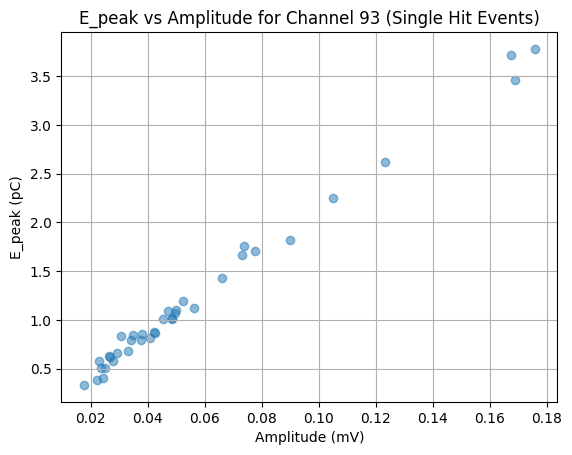

In [5]:
#amplitude vs e_peak
epeak_mask = ak.num(e_peak_PICOSEC) >= 1
valid_epeak_mask = event_mask & epeak_mask
good_epeak = e_peak_PICOSEC[valid_epeak_mask][:,0]

plt.scatter(good_amplitude, good_epeak, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('E_peak (pC)')
plt.title(f'E_peak vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()



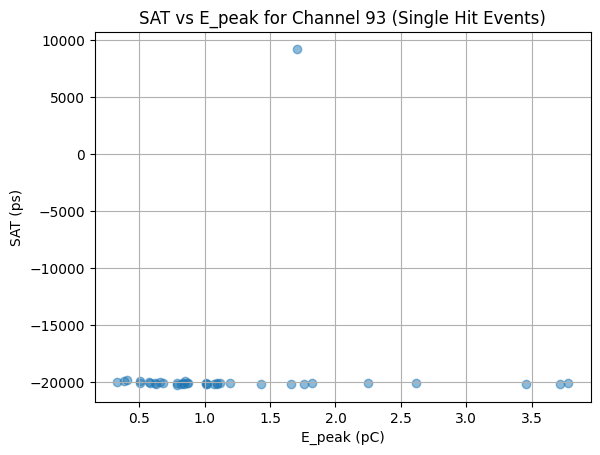

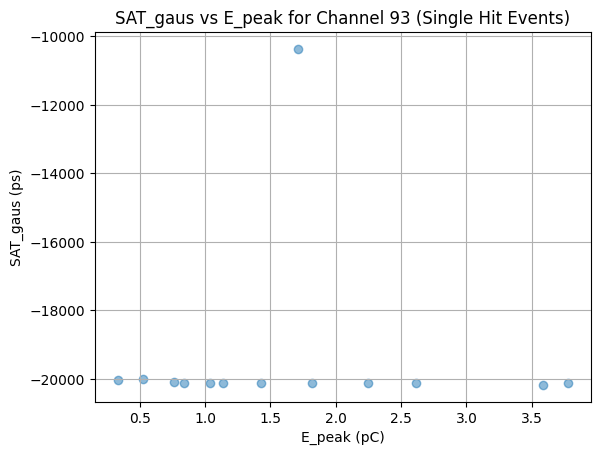

In [6]:
#sat vs charge
plt.scatter( good_epeak, good_SAT, alpha=0.5)
plt.xlabel('E_peak (pC)')
plt.ylabel('SAT (ps)')
plt.title(f'SAT vs E_peak for Channel {num_channel} (Single Hit Events)')
plt.grid()  
plt.show()


#sat_gaus vs charge


plt.scatter(bin_echarge_means, bin_means, alpha=0.5)
plt.xlabel('E_peak (pC)')
plt.ylabel('SAT_gaus (ps)')
plt.title(f'SAT_gaus vs E_peak for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()


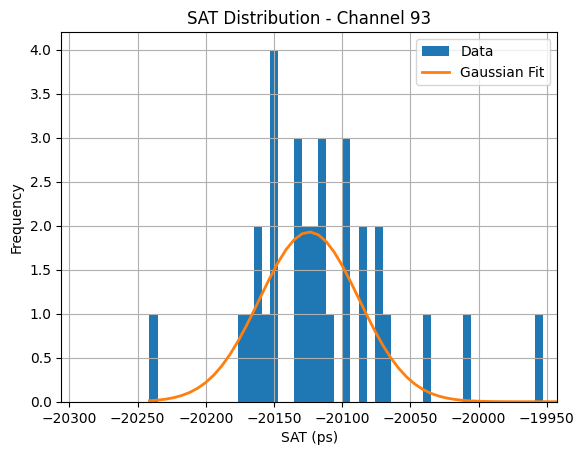

mu = -20124.18 ps, sigma = 36.36 ps


In [7]:
# pulizia dati
sat_values = ak.to_numpy(good_SAT)
sat_values = sat_values[~np.isnan(sat_values)]

mean = np.mean(sat_values)
std = np.std(sat_values)
#sat_values = sat_values[(sat_values > mean - 5*std) & (sat_values < mean + 5*std)]

# bin più ragionevoli
seg = 5000

# istogramma
hist, bin_edges = np.histogram(sat_values, bins=seg)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# fit gaussiano
popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std]
)

A_fit, mu_fit, sigma_fit = popt

# curva fit
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 5000)
y_fit = gauss(x_fit, *popt)

# plot
plt.hist(sat_values, bins=seg, alpha=1, label='Data')
plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')

plt.xlabel('SAT (ps)')
plt.ylabel('Frequency')
plt.title(f'SAT Distribution - Channel {num_channel}')
plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
plt.legend()
plt.grid()
plt.show()

print(f"mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps")

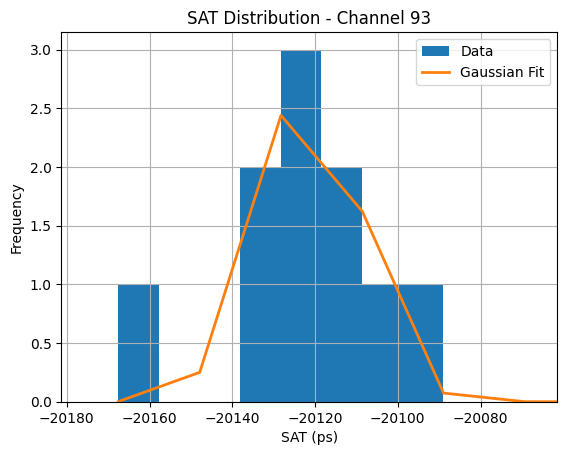

mu = -20121.39 ps, sigma = 11.99 ps


In [8]:
# pulizia dati
#sat_values = ak.to_numpy(good_SAT)
#sat_values = sat_values[~np.isnan(sat_values)]
# rimuovi NaN in modo consistente
mask = ~np.isnan(bin_means_np) & ~np.isnan(bin_std_np)

clean_means = bin_means_np[mask]
clean_std = bin_std_np[mask]

mean = np.mean(clean_means)
std = np.std(clean_std)
#sat_values = sat_values[(sat_values > mean - 5*std) & (sat_values < mean + 5*std)]

# bin più ragionevoli
seg = 1000

# istogramma
hist, bin_edges = np.histogram(clean_means, bins=seg)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# fit gaussiano
popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std]
)

A_fit, mu_fit, sigma_fit = popt

# curva fit
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit = gauss(x_fit, *popt)

# plot
plt.hist(bin_means_np, bins=seg, alpha=1, label='Data')
plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')

plt.xlabel('SAT (ps)')
plt.ylabel('Frequency')
plt.title(f'SAT Distribution - Channel {num_channel}')
plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
plt.legend()
plt.grid()
plt.show()

print(f"mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps")

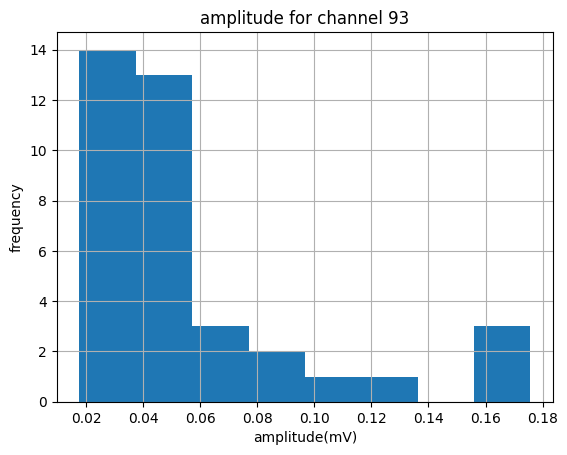

In [9]:
#amplitude plot for channel
plt.hist(good_amplitude, bins='fd', alpha=1)
plt.xlabel('amplitude(mV)')
plt.ylabel('frequency')
plt.title(f"amplitude for channel {num_channel}")
plt.grid()
plt.show()

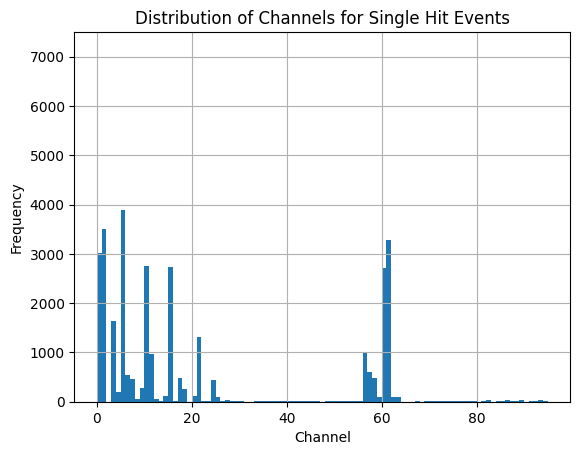

In [10]:
#most hitted channels
mask_here = single_hit_mask & valid_mask & good_track_mask
plt.hist(channel[mask_here][:, 0], bins=np.arange(0, 96, 1), alpha=1)
plt.xlabel('Channel')
plt.ylabel('Frequency')
plt.title('Distribution of Channels for Single Hit Events')
plt.ylim(0, 7500)  # Imposta un limite massimo per l'asse y
plt.grid()
plt.show()

In [11]:
flat_channels = channel[mask_here][:, 0]
flat_channels

<Array [82, 89, 82, 86, 89, 82, ..., 72, 22, 22, 22, 22] type='32071 * int32'>

In [12]:
# funziona che mi ordina i canali piu colpiti indicandomi anche il numero di eventi con 1 hit

#flat_channels = ak.flatten(channel[single_hit_mask])
#channel_counts = np.bincount(flat_channels)
channel_counts = np.bincount(flat_channels)
sorted_indices = np.argsort(channel_counts)[::-1]
sorted_channels = np.arange(96)[sorted_indices]
sorted_counts = channel_counts[sorted_indices]

print("Canali più colpiti (ordinati):")
for ch, count in zip(sorted_channels, sorted_counts):
    print(f"Canale {ch}: {count} eventi")

Canali più colpiti (ordinati):
Canale 5: 3884 eventi
Canale 1: 3502 eventi
Canale 61: 3283 eventi
Canale 0: 3021 eventi
Canale 10: 2746 eventi
Canale 15: 2738 eventi
Canale 60: 2723 eventi
Canale 3: 1641 eventi
Canale 21: 1319 eventi
Canale 56: 998 eventi
Canale 11: 973 eventi
Canale 57: 603 eventi
Canale 6: 534 eventi
Canale 58: 487 eventi
Canale 17: 476 eventi
Canale 7: 464 eventi
Canale 24: 449 eventi
Canale 9: 285 eventi
Canale 18: 263 eventi
Canale 4: 188 eventi
Canale 14: 125 eventi
Canale 20: 110 eventi
Canale 62: 100 eventi
Canale 59: 94 eventi
Canale 63: 91 eventi
Canale 25: 89 eventi
Canale 8: 64 eventi
Canale 12: 52 eventi
Canale 82: 44 eventi
Canale 93: 37 eventi
Canale 86: 35 eventi
Canale 27: 29 eventi
Canale 89: 25 eventi
Canale 13: 24 eventi
Canale 16: 22 eventi
Canale 22: 21 eventi
Canale 85: 20 eventi
Canale 51: 20 eventi
Canale 55: 20 eventi
Canale 49: 18 eventi
Canale 50: 17 eventi
Canale 46: 17 eventi
Canale 48: 17 eventi
Canale 53: 15 eventi
Canale 52: 15 eventi
C

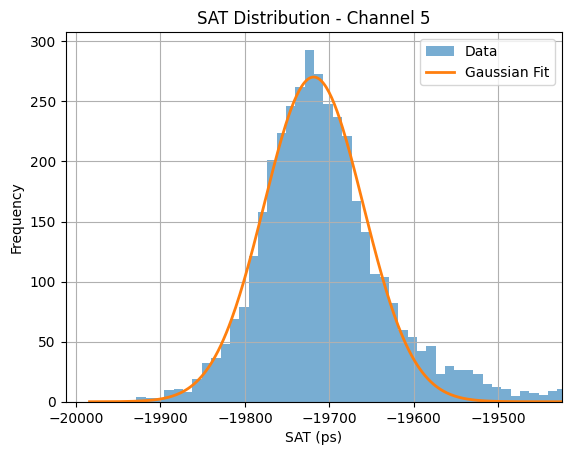

Channel 5: mu = -19718.65 ps, sigma = 58.73 ps


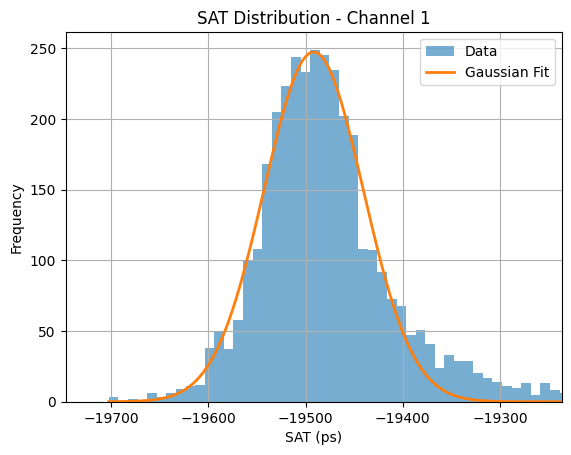

Channel 1: mu = -19491.65 ps, sigma = 51.04 ps


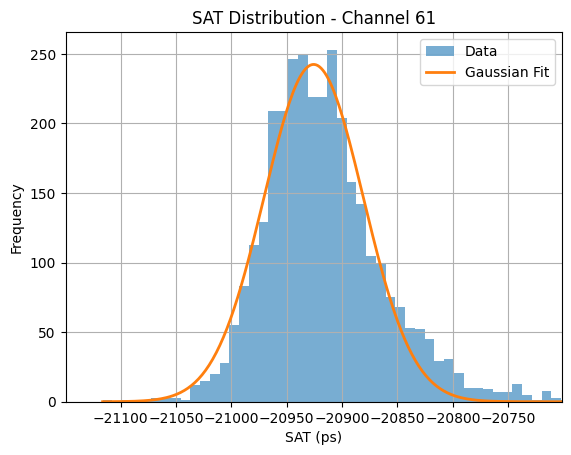

Channel 61: mu = -20925.70 ps, sigma = 44.81 ps


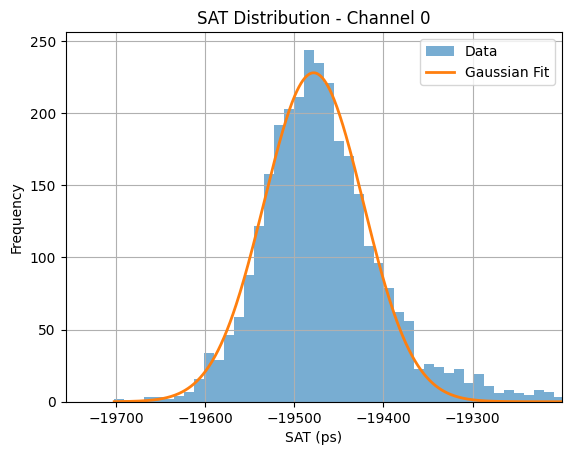

Channel 0: mu = -19478.36 ps, sigma = 55.66 ps


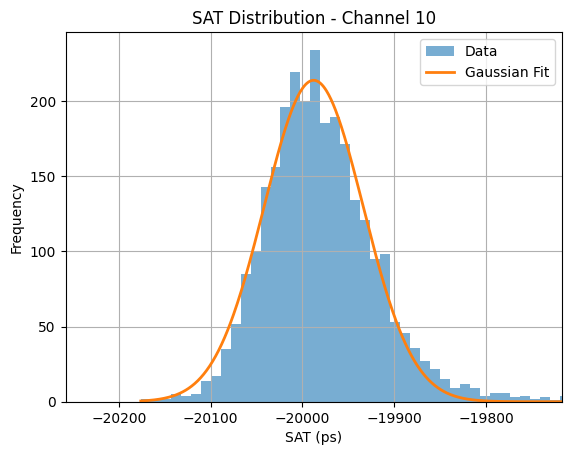

Channel 10: mu = -19987.81 ps, sigma = 54.06 ps


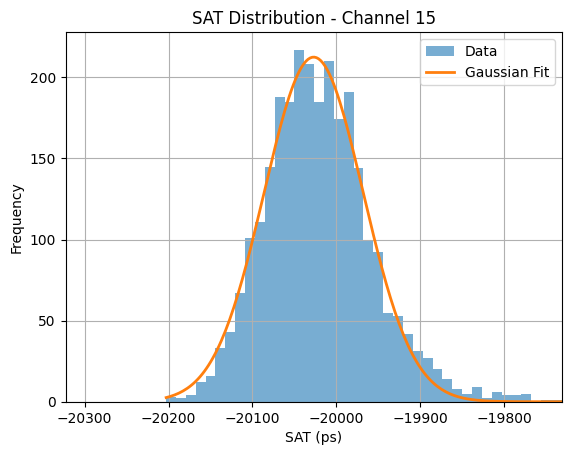

Channel 15: mu = -20026.96 ps, sigma = 59.15 ps


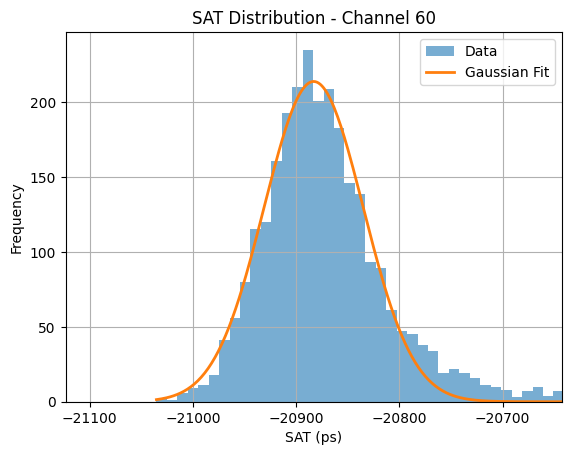

Channel 60: mu = -20883.02 ps, sigma = 48.03 ps


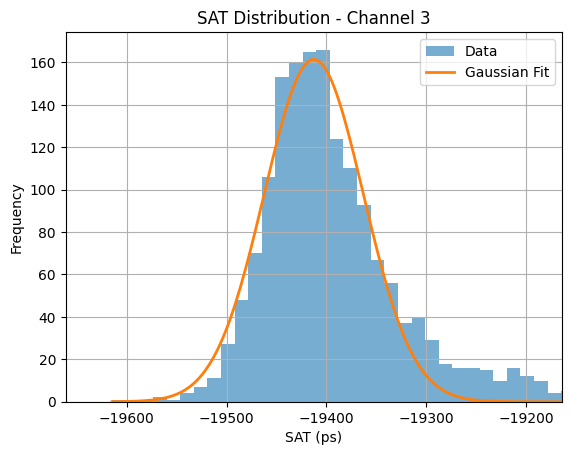

Channel 3: mu = -19412.69 ps, sigma = 49.70 ps


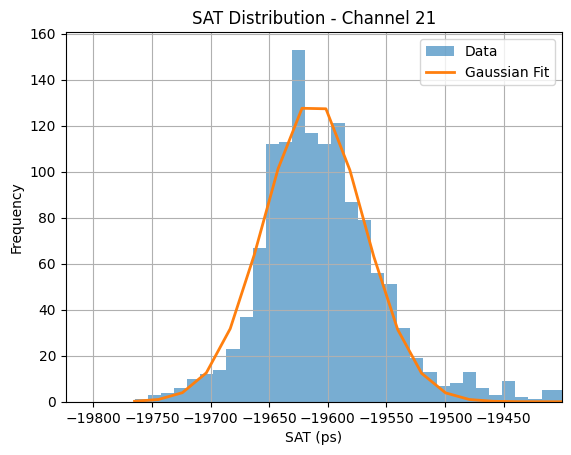

Channel 21: mu = -19611.90 ps, sigma = 42.32 ps


In [13]:
##### analisi di tutti i canali con almeno 1000 eventi
sorted_sigmas = []
sorted_channels_ok= []
for x in sorted_channels:
    ##gaus analysis
    channel_mask = channel[:, 0] == x
    single_hit_mask = hits == 1
    valid_mask = (
        (ak.num(amplitude_PICOSEC) >= 1) &
        (ak.num(cfd_PICO) >= 1) &
        good_track_mask
    )
    event_mask = channel_mask & single_hit_mask & valid_mask
    good_amplitude = amplitude_PICOSEC[event_mask][:,0]
    good_SAT = cfd_PICO[event_mask][:,0] - cfd_MCP[event_mask] - (Cell0TimeStamp_MCP[event_mask]*1e3-Cell0TimeStamp_PICOSEC[event_mask][:,0]*1e3)   
    sat_values = ak.to_numpy(good_SAT)
    sat_values = sat_values[~np.isnan(sat_values)]
    if len(sat_values) < 1000:
        continue
    mean = np.mean(sat_values)
    std = np.std(sat_values)
    bins = 'fd'
    hist, bin_edges = np.histogram(sat_values, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std],
    bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf])
)
    A_fit, mu_fit, sigma_fit = popt
    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 2000)
    y_fit = gauss(x_fit, *popt)
    plt.hist(sat_values, bins=bins, alpha=0.6, label='Data')
    plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')
    plt.xlabel('SAT (ps)')
    plt.ylabel('Frequency')
    plt.title(f'SAT Distribution - Channel {x}')
    plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
    plt.legend()
    plt.grid()
    plt.show()
    print(f"Channel {x}: mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps") 
    sorted_sigmas.append((x, sigma_fit))
    



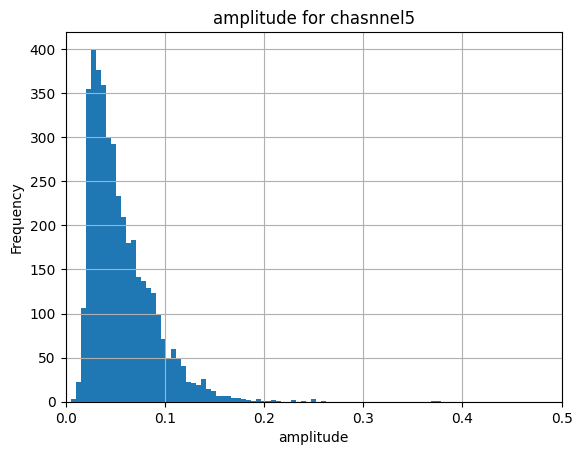

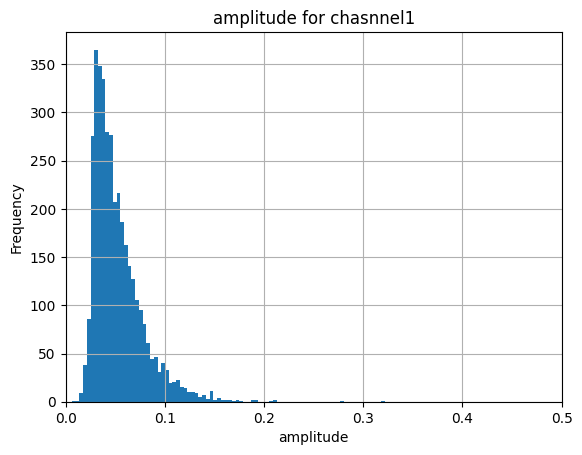

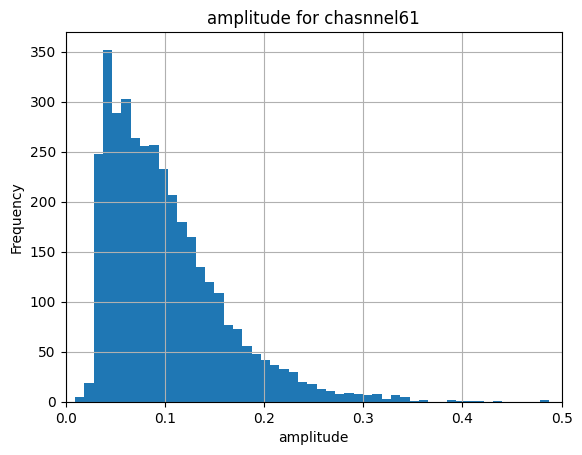

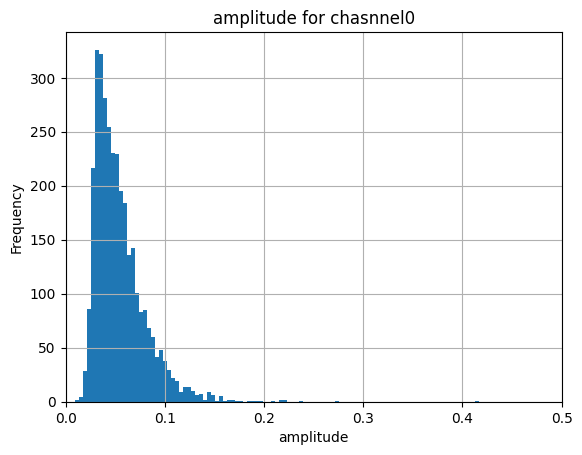

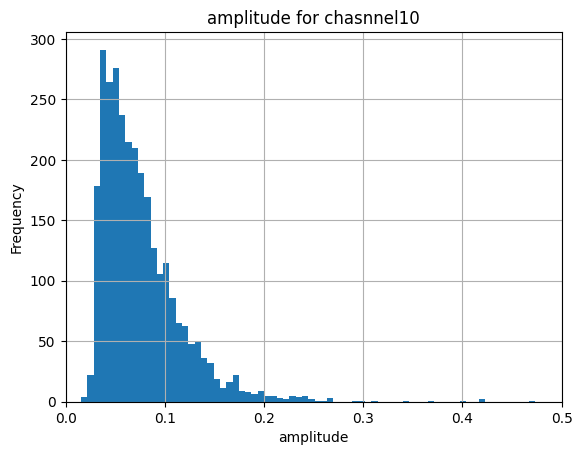

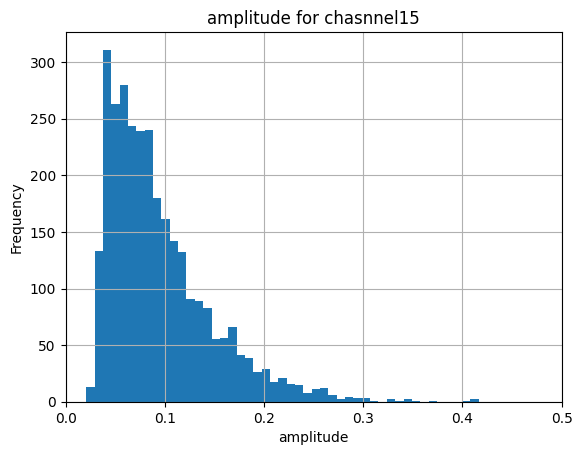

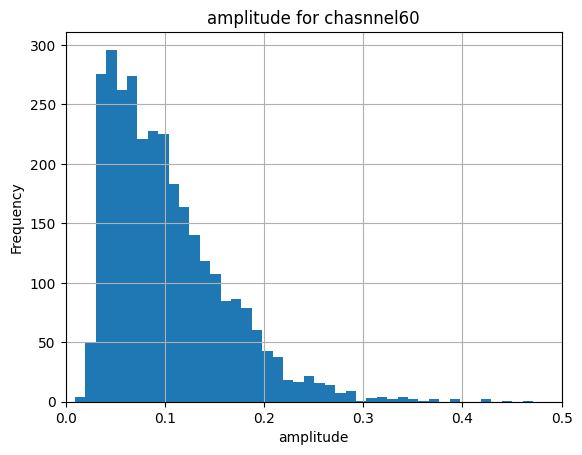

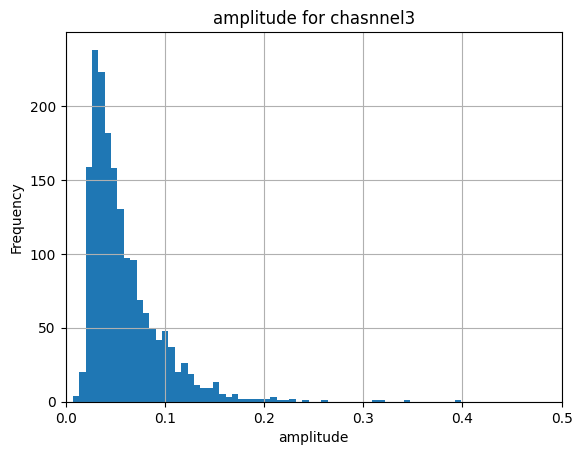

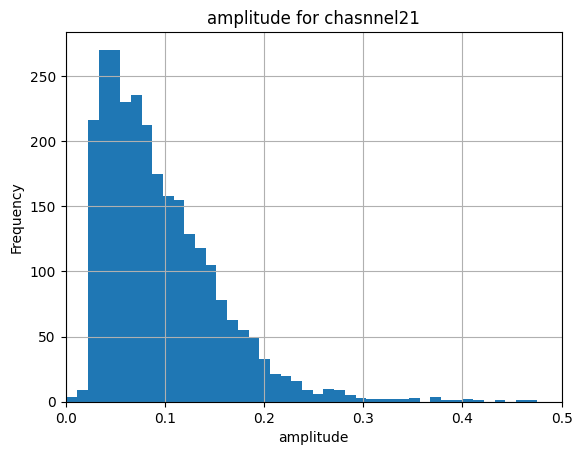

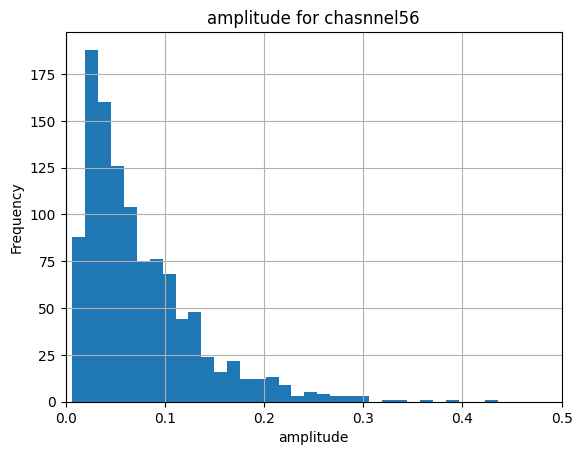

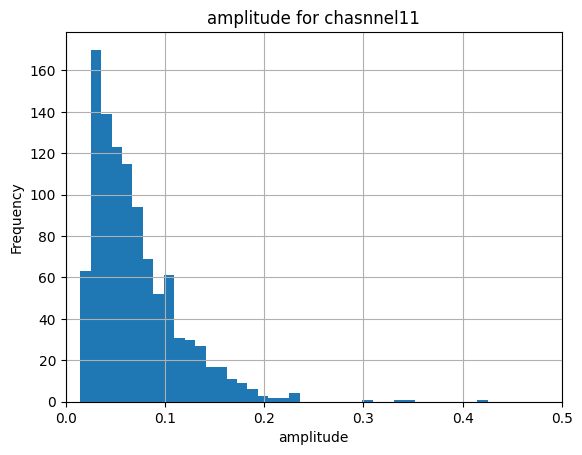

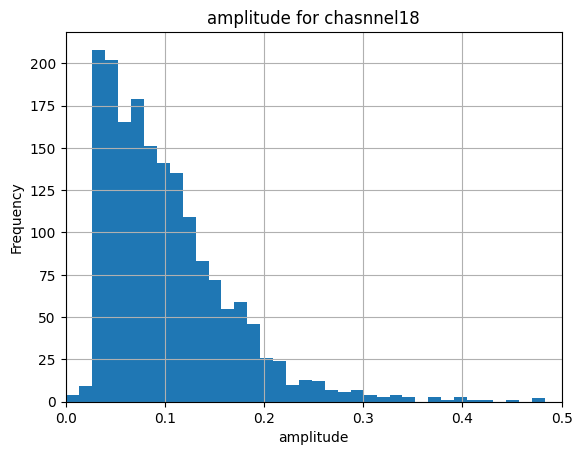

In [14]:


##### analisi di tutti i canali con almeno 1000 eventi
#### prendere la media delle amplitude per ogni canale

#sorted_sigmas = []
#sorted_channels_ok= []
mean_values = []
for x in sorted_channels:
    ##gaus analysis
    channel_mask = channel[:, 0] == x
    single_hit_mask = hits == 1
    valid_mask = (
        (ak.num(amplitude_PICOSEC) >= 1) &
        (ak.num(cfd_PICO) >= 1) 
    )

    event_mask = channel_mask & single_hit_mask & valid_mask
    good_amplitude = amplitude_PICOSEC[event_mask][:,0]
    good_SAT = cfd_PICO[event_mask][:,0] - cfd_MCP[event_mask] - (Cell0TimeStamp_MCP[event_mask]*1e3-Cell0TimeStamp_PICOSEC[event_mask][:,0]*1e3)   
    sat_values = ak.to_numpy(good_SAT)
    sat_values = sat_values[~np.isnan(sat_values)]
    if len(sat_values) < 1000:
        continue
    mean_values.append((x, np.mean(good_amplitude)))
    mask_here = single_hit_mask & valid_mask 
    plt.hist(good_amplitude, bins='fd', alpha=1)
    plt.xlabel('amplitude')
    plt.ylabel('Frequency')
    plt.title(f'amplitude for chasnnel{x}')
    #plt.ylim(0, 7500)  # Imposta un limite massimo per l'asse y
    plt.xlim(0,0.5)
    plt.grid()
    plt.show()
           

        

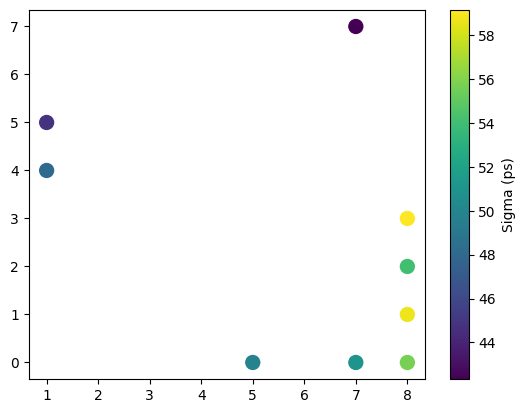

In [15]:
positions = np.loadtxt("november_channel.txt", delimiter="\t", skiprows=1)

channel_numbers = positions[:, 0].astype(int)
x_positions = positions[:, 1]
y_positions = positions[:, 2]

channel_position_map = {ch: (x, y) for ch, x, y in zip(channel_numbers, x_positions, y_positions)}

# CREA sigma_map
sigma_map = np.full(96, np.nan)
for ch, sigma in sorted_sigmas:
    sigma_map[ch] = sigma

# FILTRA SOLO QUELLI VALIDI
x = []
y = []
c = []

for ch in channel_numbers:
    sigma = sigma_map[ch]
    if not np.isnan(sigma):
        x.append(channel_position_map[ch][0])
        y.append(channel_position_map[ch][1])
        c.append(sigma)

plt.scatter(x, y, c=c, cmap='viridis', s=100)
plt.colorbar(label='Sigma (ps)')
#plt.xlim(0, 10)
#plt.ylim(-5, 10)
plt.show()

In [16]:
print(sorted_sigmas[:10])

[(np.int64(5), np.float64(58.72528088868092)), (np.int64(1), np.float64(51.04040987124094)), (np.int64(61), np.float64(44.805679375441045)), (np.int64(0), np.float64(55.66289853140508)), (np.int64(10), np.float64(54.05887577431169)), (np.int64(15), np.float64(59.15310589715296)), (np.int64(60), np.float64(48.029932685862576)), (np.int64(3), np.float64(49.70222737204704)), (np.int64(21), np.float64(42.324324368193786))]


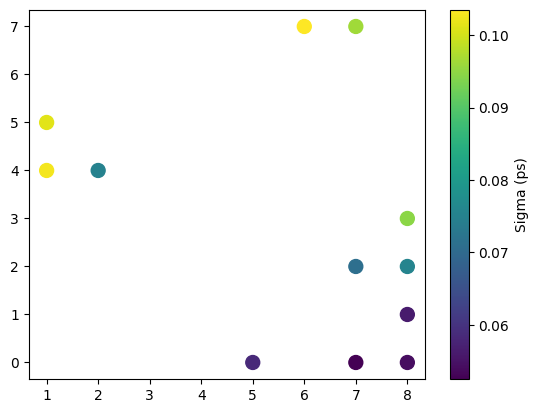

In [17]:
positions = np.loadtxt("november_channel.txt", delimiter="\t", skiprows=1)

channel_numbers = positions[:, 0].astype(int)
x_positions = positions[:, 1]
y_positions = positions[:, 2]

channel_position_map = {ch: (x, y) for ch, x, y in zip(channel_numbers, x_positions, y_positions)}

# CREA sigma_map
sigma_map = np.full(96, np.nan)
for ch, sigma in mean_values:
    sigma_map[ch] = sigma

# FILTRA SOLO QUELLI VALIDI
x = []
y = []
c = []

for ch in channel_numbers:
    sigma = sigma_map[ch]
    if not np.isnan(sigma):
        x.append(channel_position_map[ch][0])
        y.append(channel_position_map[ch][1])
        c.append(sigma)

plt.scatter(x, y, c=c, cmap='viridis', s=100)
plt.colorbar(label='Sigma (ps)')
#plt.xlim(0, 10)
#plt.ylim(-5, 10)
plt.show()

In [18]:

from scipy.special import gamma

def polya_fit(Q, A, Q_mean, theta):
    """
    Polya per fit di ampiezze (non normalizzata)

    Parametri:
    ----------
    Q : array
        Ampiezza / carica
    A : float
        Normalizzazione (area / numero eventi)
    Q_mean : float
        Carica media
    theta : float
        Parametro di Polya

    Ritorna:
    -------
    Valori della funzione per il fit
    """
    coeff = (1 + theta)**(1 + theta) / gamma(1 + theta)
    x = Q / Q_mean
    return A * coeff * (x**theta) * np.exp(-(1 + theta) * x) / Q_mean

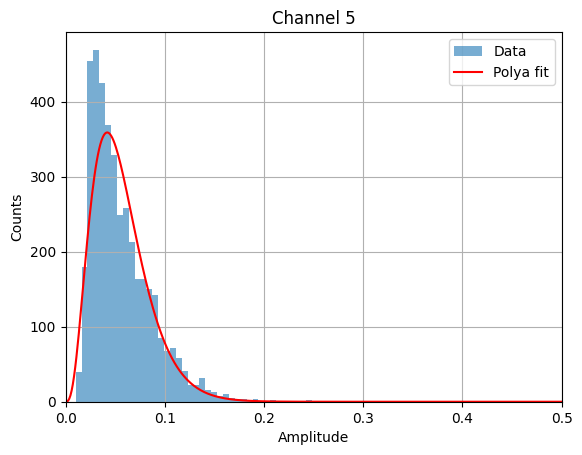


Channel 5
Entries = 4079
A      = 22.59
<Q>    = 0.0561
theta  = 2.943
-------------------------



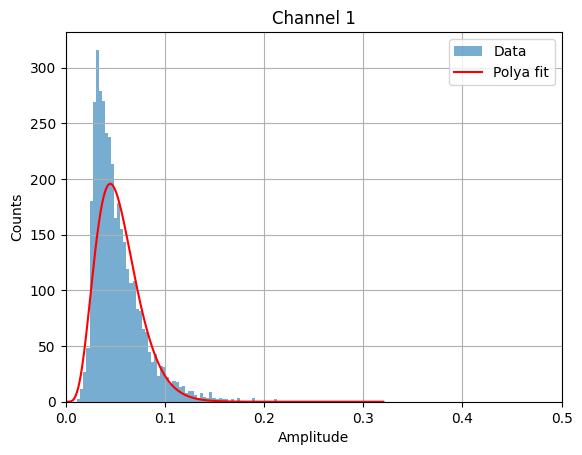


Channel 1
Entries = 3761
A      = 10.03
<Q>    = 0.0540
theta  = 5.000
-------------------------



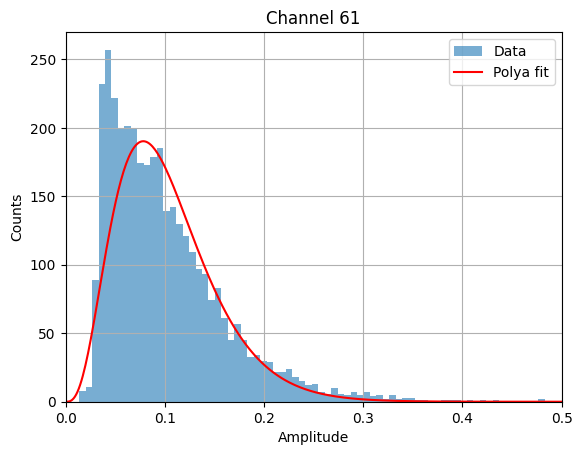


Channel 61
Entries = 3666
A      = 21.54
<Q>    = 0.1030
theta  = 3.161
-------------------------



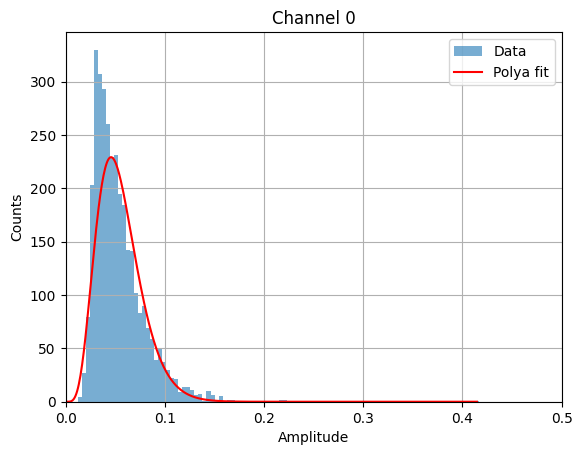


Channel 0
Entries = 3330
A      = 11.96
<Q>    = 0.0549
theta  = 5.000
-------------------------



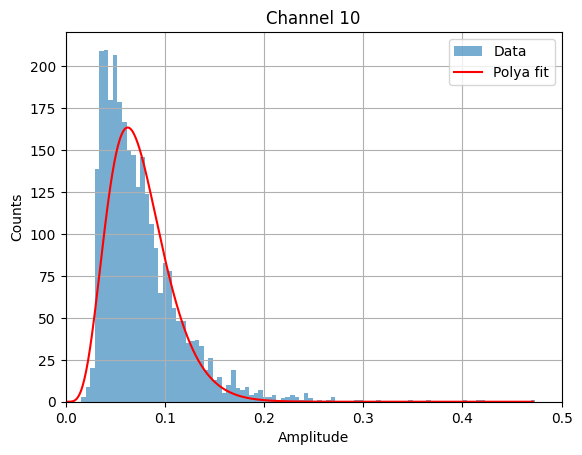


Channel 10
Entries = 2927
A      = 11.66
<Q>    = 0.0751
theta  = 5.000
-------------------------



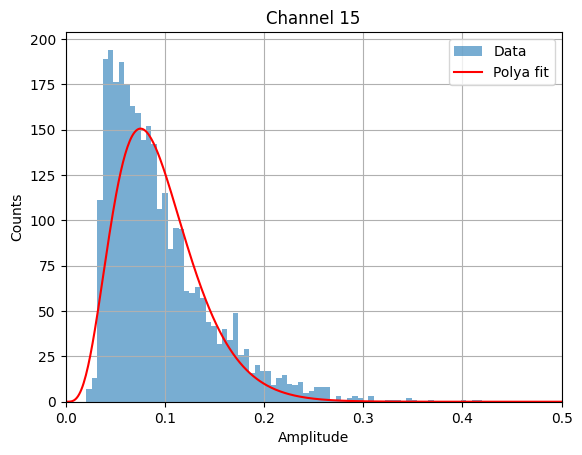


Channel 15
Entries = 3044
A      = 14.48
<Q>    = 0.0942
theta  = 4.031
-------------------------



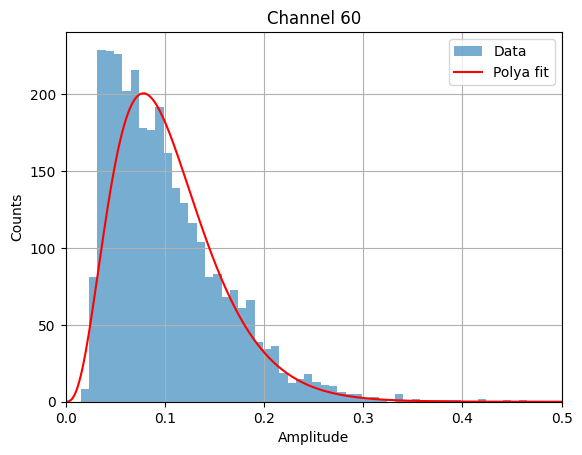


Channel 60
Entries = 3068
A      = 23.50
<Q>    = 0.1047
theta  = 2.971
-------------------------



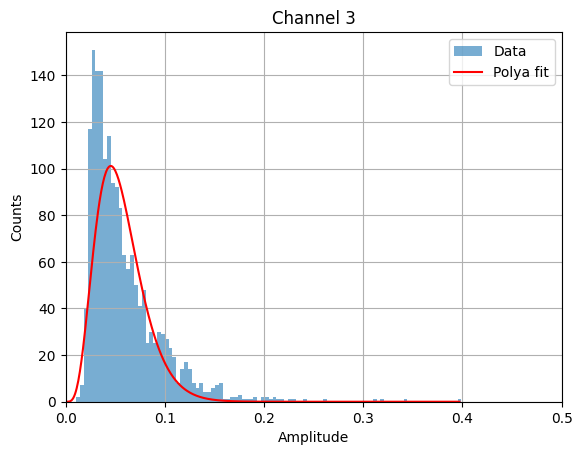


Channel 3
Entries = 1753
A      = 5.61
<Q>    = 0.0558
theta  = 4.384
-------------------------



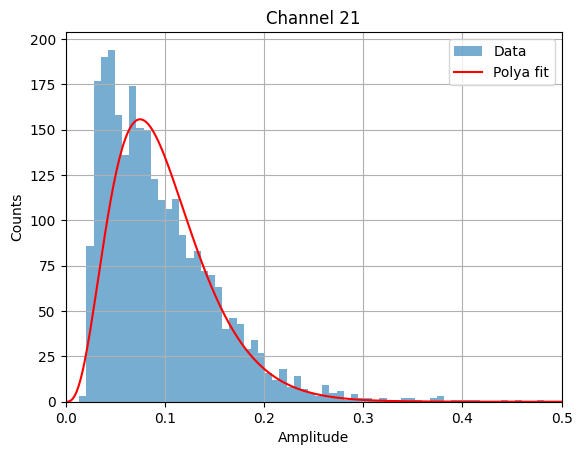


Channel 21
Entries = 2685
A      = 16.97
<Q>    = 0.0990
theta  = 3.137
-------------------------



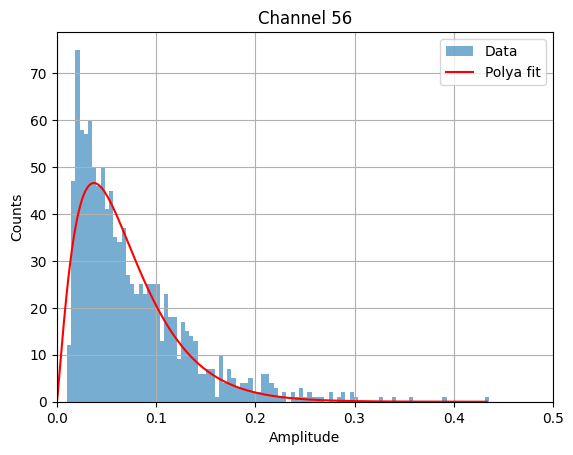


Channel 56
Entries = 1105
A      = 4.30
<Q>    = 0.0689
theta  = 1.183
-------------------------



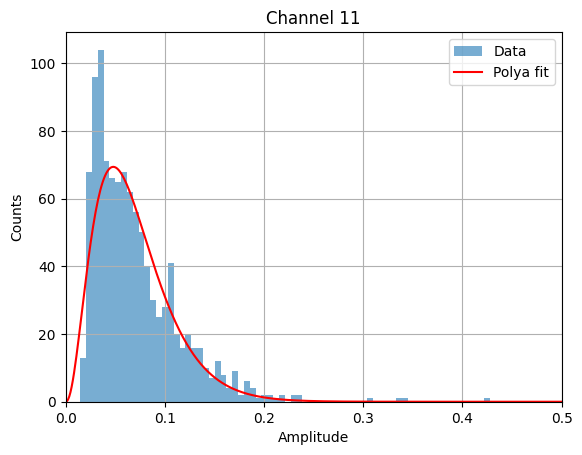


Channel 11
Entries = 1050
A      = 5.71
<Q>    = 0.0689
theta  = 2.300
-------------------------



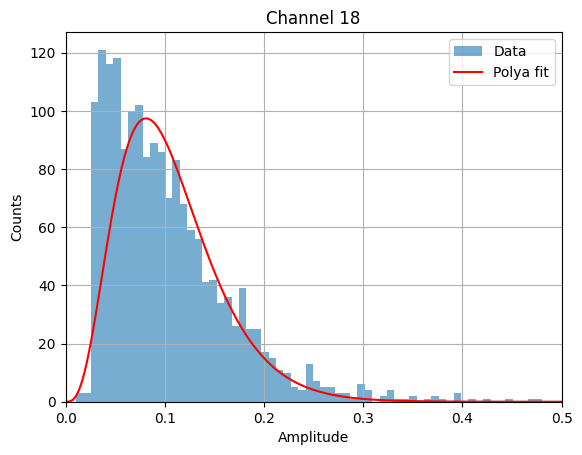


Channel 18
Entries = 1751
A      = 11.15
<Q>    = 0.1055
theta  = 3.308
-------------------------



In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

mean_values = []

for x in sorted_channels:

    #mask
    channel_mask = channel[:, 0] == x
    single_hit_mask = hits == 1
    valid_mask = (
        (ak.num(amplitude_PICOSEC) >= 1) &
        (ak.num(cfd_PICO) >= 1)
    )

    event_mask = channel_mask & single_hit_mask & valid_mask

    # not used
    good_SAT = (
        cfd_PICO[event_mask][:, 0]
        - cfd_MCP[event_mask]
        - (Cell0TimeStamp_MCP[event_mask]*1e3
           - Cell0TimeStamp_PICOSEC[event_mask][:, 0]*1e3)
    )

    sat_values = ak.to_numpy(good_SAT)
    sat_values = sat_values[~np.isnan(sat_values)]

    if len(sat_values) < 1000:
        continue

    #amplitude conversion ak to numpy
    good_amplitude = ak.to_numpy(amplitude_PICOSEC[event_mask][:, 0])
    good_amplitude = good_amplitude[~np.isnan(good_amplitude)]

    #noisy cut
    good_amplitude = good_amplitude[good_amplitude > 0.01]

    if len(good_amplitude) < 1000:
        continue

    #histo
    counts, bin_edges = np.histogram(good_amplitude, bins=100)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    mask = counts > 0
    x_fit = bin_centers[mask]
    y_fit = counts[mask]

    #guess
    p0 = [np.sum(counts), np.mean(good_amplitude), 0.5]

    #err
    sigma = np.sqrt(y_fit)
    sigma[sigma == 0] = 1

    # --- Fit Polya ---
    try:
        params, cov = curve_fit(
            polya_fit,
            x_fit,
            y_fit,
            p0=p0,
            sigma=sigma,
            absolute_sigma=True,
            bounds=([0, 0, 0], [np.inf, np.inf, 5]),
            maxfev=10000
        )
    except RuntimeError:
        print(f"Fit failed for channel {x}")
        continue

    A_fit, Qmean_fit, theta_fit = params

    
    mean_values.append((x, Qmean_fit))  

    
    x_plot = np.linspace(0, max(bin_centers), 500)

    plt.figure()
    plt.hist(good_amplitude, bins=100, alpha=0.6, label='Data')
    plt.plot(x_plot, polya_fit(x_plot, *params), 'r-', label='Polya fit')

    plt.xlabel('Amplitude')
    plt.ylabel('Counts')
    plt.title(f'Channel {x}')
    plt.xlim(0, 0.5)
    plt.grid()
    plt.legend()
    plt.show()

    # --- Stampa risultati ---
    print(f"""
Channel {x}
Entries = {len(good_amplitude)}
A      = {A_fit:.2f}
<Q>    = {Qmean_fit:.4f}
theta  = {theta_fit:.3f}
-------------------------
""")

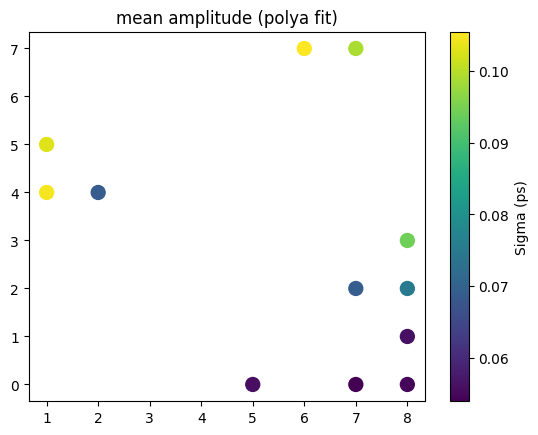

In [20]:
positions = np.loadtxt("november_channel.txt", delimiter="\t", skiprows=1)

channel_numbers = positions[:, 0].astype(int)
x_positions = positions[:, 1]
y_positions = positions[:, 2]

channel_position_map = {ch: (x, y) for ch, x, y in zip(channel_numbers, x_positions, y_positions)}

# CREA sigma_map
sigma_map = np.full(96, np.nan)
for ch, sigma in mean_values:
    sigma_map[ch] = sigma

# FILTRA SOLO QUELLI VALIDI
x = []
y = []
c = []

for ch in channel_numbers:
    sigma = sigma_map[ch]
    if not np.isnan(sigma):
        x.append(channel_position_map[ch][0])
        y.append(channel_position_map[ch][1])
        c.append(sigma)
plt.title("mean amplitude (polya fit)")
plt.scatter(x, y, c=c, cmap='viridis', s=100)
plt.colorbar(label='Sigma (ps)')
#plt.xlim(0, 10)
#plt.ylim(-5, 10)
plt.show()

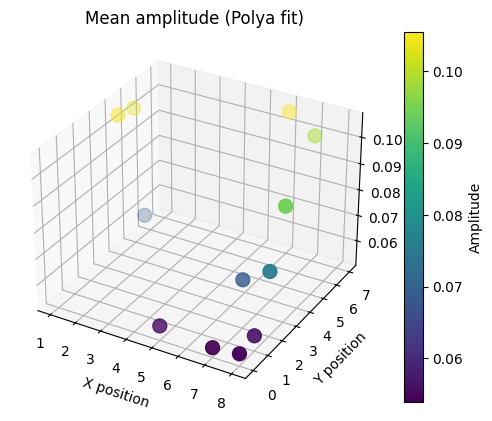

In [21]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x, y, c, c=c, cmap='viridis', s=100)

ax.set_title("Mean amplitude (Polya fit)")
ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Amplitude (<Q>)")

fig.colorbar(sc, ax=ax, label='Amplitude')

plt.show()

In [22]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=x,
    y=y,
    z=c,
    mode='markers',
    marker=dict(
        size=5,
        color=c,
        colorscale='Viridis',
        colorbar=dict(title='Amplitude'),
        opacity=0.8
    )
)])

fig.update_layout(
    title='Mean amplitude (Polya fit)',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='<Q>'
    )
)

fig.show()